# PRISEC-IV — Benchmark Results Analysis

This notebook loads, cleans, and visualizes the four benchmark phases used
in the PRISEC-IV 
1. **Phase 1** — single ciphers (AES-128/192/256, ChaCha20, SPECK, RECTANGLE, HIGHT)
2. **Phase 2** — ECC key exchange + single cipher
3. **Phase 3** — dual-layer cascades (cipher → cipher)
4. **Phase 4** — ECC key exchange + dual-layer cascade

**Benchmark environment:** 2 vCPU, 1st/2nd-gen Intel Xeon Platinum, 2.50 GHz baseline, x86,
1 GB RAM. Values are therefore useful for *relative* comparison between
configurations.

## 1. Imports

In [2]:
import os

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 20)

%matplotlib inline

## 2. Configuration

Paths to the four result CSVs, output directory for figures, canonical
size ordering, and shared plotting style

In [21]:
CSV_DIR = "../benchmarks"
OUT_DIR = "figures"
os.makedirs(OUT_DIR, exist_ok=True)

SIZE_ORDER = ["1KB", "5KB", "10KB", "50KB", "100KB", "1MB", "5MB", "10MB", "50MB"]
SIZE_BYTES = {"1KB": 1e3, "5KB": 5e3, "10KB": 1e4, "50KB": 5e4, "100KB": 1e5,
              "1MB": 1e6, "5MB": 5e6, "10MB": 1e7, "50MB": 5e7}


PALETTE = [
    "#D53E4F",
    "#F46D43",
    "#FDAE61",
    "#FEE08B",
    "#E6F598",
    "#ABDAA4",
    "#66C2A5",
    "#3288BD",
    "#2B4875",
]
MARKERS = ["o", "s", "^", "D", "v", "P", "X", "*", "h"]
LINESTYLES = ["-", "--", "-.", ":", "-", "--", "-.", ":", "-"]

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.edgecolor": "#333333",
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#DDDDDD",
    "grid.linewidth": 0.6,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "legend.frameon": False,
})

## 3. Load raw data

In [4]:
p1 = pd.read_csv(os.path.join(CSV_DIR, "phase1_results.csv"))
print(f"phase1: {p1.shape[0]} rows, columns = {list(p1.columns)}")

p1["size_bytes"] = p1["data_size"].map(SIZE_BYTES)
p1["size_kb"] = p1["size_bytes"] / 1024

p1["mem_overhead_enc_kb"] = p1["memory_enc_kb"] - p1["size_kb"]
p1["mem_overhead_dec_kb"] = p1["memory_dec_kb"] - p1["size_kb"]
p1["mem_overhead_enc_pct"] = 100 * p1["mem_overhead_enc_kb"] / p1["size_kb"]

p1["dec_enc_ratio"] = p1["dec_ms"] / p1["enc_ms"]


phase1: 63 rows, columns = ['algorithm', 'data_size', 'enc_ms', 'dec_ms', 'throughput_enc_mbps', 'throughput_dec_mbps', 'latency_us', 'memory_enc_kb', 'memory_dec_kb']


## 4. Helper Functions

In [5]:
def fmt_ms(v):
    """Compact ms formatting, decimals scaled to magnitude."""
    if pd.isna(v):
        return ""
    if v >= 100:
        return f"{v:.0f}"
    if v >= 1:
        return f"{v:.1f}"
    if v >= 0.01:
        return f"{v:.3f}"
    return f"{v:.4f}"


def fmt_mbps(v):
    """Compact Mbps formatting, comma-grouped above 1000."""
    if pd.isna(v):
        return ""
    if v >= 1000:
        return f"{v:,.0f}"
    if v >= 1:
        return f"{v:.1f}"
    return f"{v:.3f}"


def fmt_kb(v):
    """Compact KB formatting."""
    if pd.isna(v):
        return ""
    if v >= 100:
        return f"{v:,.0f}"
    if v >= 1:
        return f"{v:.2f}"
    return f"{v:.3f}"


- `bar_chart_with_table` — grouped bar chart + table (used for raw time values)
- `line_chart_with_table` — single-panel line chart + table (skips any
  series that's entirely NaN, e.g. ChaCha20 for latency, since it's a
  stream cipher with no block size)
- `side_by_side_line_tables` — two-panel version (encryption /
  decryption side by side), each with its own table underneath

In [31]:
def side_by_side_bar_tables(df, category_col, enc_col, dec_col, out_name,
                             size_order=SIZE_ORDER, figsize=(18, 8.5),
                             row_label_width=0.20, table_fontsize=8):
    categories = sorted(df[category_col].unique())
    sizes = [s for s in size_order if s in df["data_size"].unique()]
    n_cat = len(categories)
    x = np.arange(len(sizes))
    bar_width = 0.82 / n_cat
    data_col_width = (1.0 - row_label_width) / len(sizes)

    fig, axes = plt.subplots(2, 2, figsize=figsize,
        gridspec_kw={"height_ratios": [3.2, 1.8], "hspace": 0.05, "wspace": 0.15})
    (ax_enc, ax_dec), (tax_enc, tax_dec) = axes

    for ax, tax, value_col, subtitle in [(ax_enc, tax_enc, enc_col, "Encryption time"),
                                          (ax_dec, tax_dec, dec_col, "Decryption time")]:
        cell_text, row_colors = [], []
        for i, cat in enumerate(categories):
            sub = df[df[category_col] == cat].set_index("data_size")
            heights = [sub.loc[s, value_col] if s in sub.index else np.nan for s in sizes]
            offset = (i - (n_cat - 1) / 2) * bar_width
            color = PALETTE[i % len(PALETTE)]
            ax.bar(x + offset, heights, width=bar_width * 0.92, color=color,
                   edgecolor="white", linewidth=0.4, zorder=3)
            # Category name is now the FIRST DATA COLUMN, not rowLabels —
            # rowLabels draws outside the table's bbox and was the actual
            # cause of the overlap, not a font/width sizing issue.
            cell_text.append([cat] + [fmt_ms(h) for h in heights])
            row_colors.append(color)

        ax.set_yscale("log")
        ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
        ax.yaxis.set_minor_formatter(mticker.NullFormatter())
        ax.set_xticks(x); ax.set_xticklabels([])
        ax.set_ylabel("Time (ms, log scale)")
        ax.set_title(subtitle, fontsize=11, fontweight="bold")

        tax.axis("off")
        col_labels = [""] + sizes
        col_widths = [row_label_width] + [data_col_width] * len(sizes)
        the_table = tax.table(cellText=cell_text, colLabels=col_labels, colWidths=col_widths,
                               cellLoc="center", loc="upper center", bbox=[0.0, 0.0, 1.0, 1.0])
        the_table.auto_set_font_size(False)
        the_table.set_fontsize(table_fontsize)

        for (row, col), cell in the_table.get_celld().items():
            cell.set_edgecolor("white")
            if row == 0:
                cell.set_text_props(fontweight="bold")
                continue
            if col == 0:
                cell.set_facecolor(row_colors[row - 1])
                cell.set_text_props(color="white", fontweight="bold", ha="left")
                cell.PAD = 0.02

    fig.savefig(f"{OUT_DIR}/{out_name}.png", dpi=200, bbox_inches="tight")
    fig.savefig(f"{OUT_DIR}/{out_name}.pdf", bbox_inches="tight")
    plt.show()

In [47]:
def line_chart_with_table(df, category_col, value_col, title, out_name, value_fmt=fmt_ms,
                           ylabel="Time (ms, log scale)", size_order=SIZE_ORDER, figsize=(13, 9),
                           row_label_width=0.20, table_fontsize=8, legend_ncol=4):
    categories = sorted(df[category_col].unique())
    sizes = [s for s in size_order if s in df["data_size"].unique()]
    x = np.arange(len(sizes))
    data_col_width = (1.0 - row_label_width) / len(sizes)

    fig, (ax, tax) = plt.subplots(2, 1, figsize=figsize,
        gridspec_kw={"height_ratios": [3.2, 1.6], "hspace": 0.05})

    cell_text, row_colors, kept_categories = [], [], []
    for i, cat in enumerate(categories):
        sub = df[df[category_col] == cat].set_index("data_size")
        values = [sub.loc[s, value_col] if s in sub.index else np.nan for s in sizes]
        if all(pd.isna(v) for v in values):
            continue
        color = PALETTE[i % len(PALETTE)]
        ax.plot(x, values, marker=MARKERS[i % len(MARKERS)], linestyle=LINESTYLES[i % len(LINESTYLES)],
                color=color, markersize=6, linewidth=1.6, zorder=3, label=cat)
        # Category name as a real first column, not rowLabels (same fix as the bar/side-by-side versions)
        cell_text.append([cat] + [value_fmt(v) for v in values])
        row_colors.append(color)
        kept_categories.append(cat)

    ax.set_yscale("log")
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    ax.set_xticks(x); ax.set_xticklabels([])
    ax.set_xlim(-0.3, len(sizes) - 0.7)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=12)

    tax.axis("off")
    col_labels = [""] + sizes
    col_widths = [row_label_width] + [data_col_width] * len(sizes)
    the_table = tax.table(cellText=cell_text, colLabels=col_labels, colWidths=col_widths,
        cellLoc="center", loc="upper center", bbox=[0.0, 0.0, 1.0, 1.0])
    the_table.auto_set_font_size(False)
    the_table.set_fontsize(table_fontsize)
    for (row, col), cell in the_table.get_celld().items():
        cell.set_edgecolor("white")
        if row == 0:
            cell.set_text_props(fontweight="bold")
            continue
        if col == 0:
            cell.set_facecolor(row_colors[row - 1])
            cell.set_text_props(color="white", fontweight="bold", ha="left")
            cell.PAD = 0.02

    # New: legend of the line shapes/colors, same wrapping approach as the side-by-side charts
    handles, labels = ax.get_legend_handles_labels()
    ncol = min(legend_ncol, len(kept_categories))
    fig.legend(handles, labels, loc="lower center", ncol=ncol,
               bbox_to_anchor=(0.5, 1.0), fontsize=8, frameon=False)

    fig.savefig(f"{OUT_DIR}/{out_name}.png", dpi=200, bbox_inches="tight")
    fig.savefig(f"{OUT_DIR}/{out_name}.pdf", bbox_inches="tight")
    plt.show()

In [42]:
def side_by_side_line_tables(df, category_col, enc_col, dec_col, out_name,
                              value_fmt=fmt_mbps, ylabel="Throughput (Mbps, log scale)",
                              size_order=SIZE_ORDER, figsize=(16, 9.5),
                              row_label_width=0.20, table_fontsize=7.5, legend_ncol=4):
    categories = sorted(df[category_col].unique())
    sizes = [s for s in size_order if s in df["data_size"].unique()]
    x = np.arange(len(sizes))
    data_col_width = (1.0 - row_label_width) / len(sizes)

    fig, axes = plt.subplots(2, 2, figsize=figsize,
        gridspec_kw={"height_ratios": [3.2, 1.6], "hspace": 0.05, "wspace": 0.15})
    (ax_enc, ax_dec), (tax_enc, tax_dec) = axes

    for ax, tax, value_col, subtitle in [(ax_enc, tax_enc, enc_col, "Encryption"),
                                          (ax_dec, tax_dec, dec_col, "Decryption")]:
        cell_text, row_colors = [], []
        for i, cat in enumerate(categories):
            sub = df[df[category_col] == cat].set_index("data_size")
            values = [sub.loc[s, value_col] if s in sub.index else np.nan for s in sizes]
            color = PALETTE[i % len(PALETTE)]
            ax.plot(x, values, marker=MARKERS[i % len(MARKERS)], linestyle=LINESTYLES[i % len(LINESTYLES)],
                    color=color, markersize=5, linewidth=1.4, zorder=3, label=cat)
            cell_text.append([cat] + [value_fmt(v) for v in values])
            row_colors.append(color)

        ax.set_yscale("log")
        ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
        ax.yaxis.set_minor_formatter(mticker.NullFormatter())
        ax.set_xticks(x); ax.set_xticklabels([])
        ax.set_xlim(-0.3, len(sizes) - 0.7)
        ax.set_ylabel(ylabel)
        ax.set_title(subtitle, fontsize=11, fontweight="bold")

        tax.axis("off")
        col_labels = [""] + sizes
        col_widths = [row_label_width] + [data_col_width] * len(sizes)
        the_table = tax.table(cellText=cell_text, colLabels=col_labels, colWidths=col_widths,
            cellLoc="center", loc="upper center", bbox=[0.0, 0.0, 1.0, 1.0])
        the_table.auto_set_font_size(False)
        the_table.set_fontsize(table_fontsize)
        for (row, col), cell in the_table.get_celld().items():
            cell.set_edgecolor("white")
            if row == 0:
                cell.set_text_props(fontweight="bold")
                continue
            if col == 0:
                cell.set_facecolor(row_colors[row - 1])
                cell.set_text_props(color="white", fontweight="bold", ha="left")
                cell.PAD = 0.02

    handles, labels = ax_enc.get_legend_handles_labels()
    ncol = min(legend_ncol, len(categories))
    fig.legend(handles, labels, loc="lower center", ncol=ncol,
               bbox_to_anchor=(0.5, 1.0), fontsize=8, frameon=False)

    fig.savefig(f"{OUT_DIR}/{out_name}.png", dpi=200, bbox_inches="tight")
    fig.savefig(f"{OUT_DIR}/{out_name}.pdf", bbox_inches="tight")
    plt.show()

## 5. Phase 1

### 5.1 Encryption & Decryption times for all sizes for every single cipher

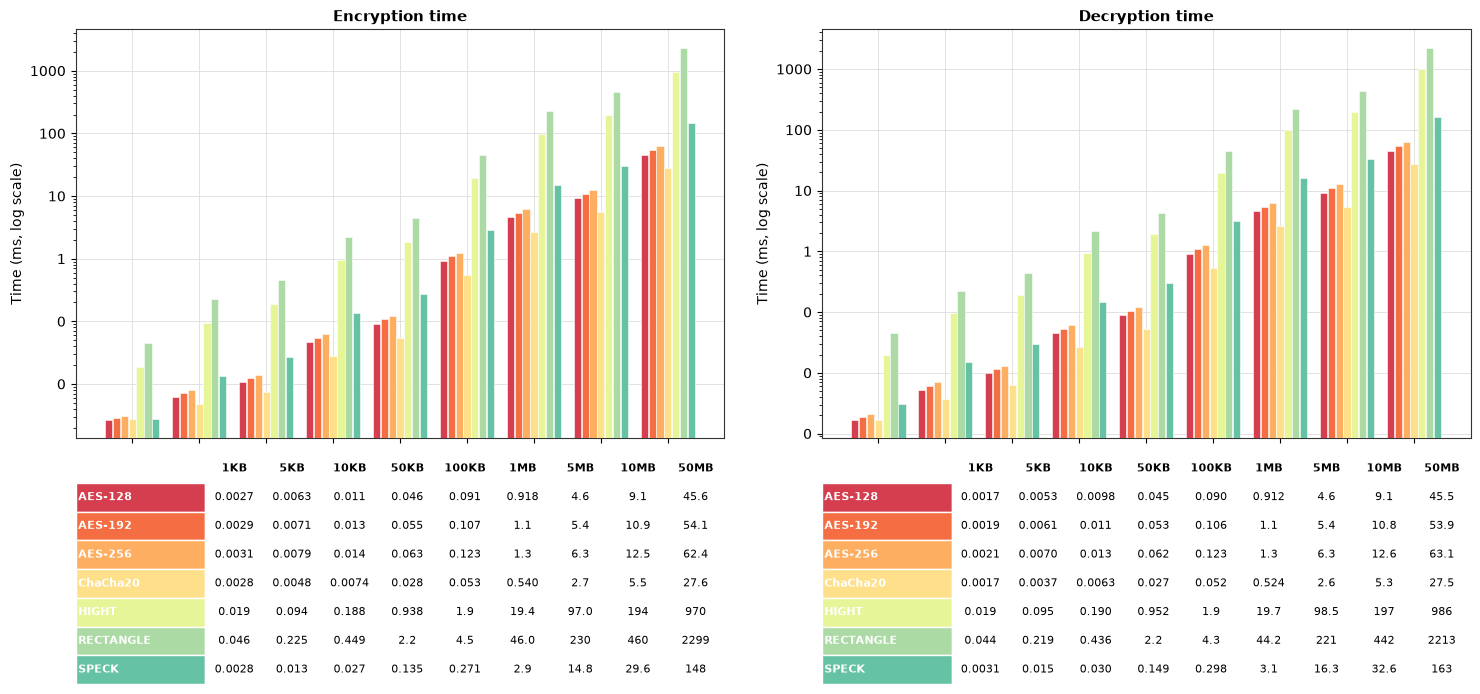

In [33]:
side_by_side_bar_tables(p1, "algorithm", "enc_ms", "dec_ms", "fig_phase1_enc_dec_time")

### 5.2 Encryption & Decryption throughput for all sizes for every single cipher

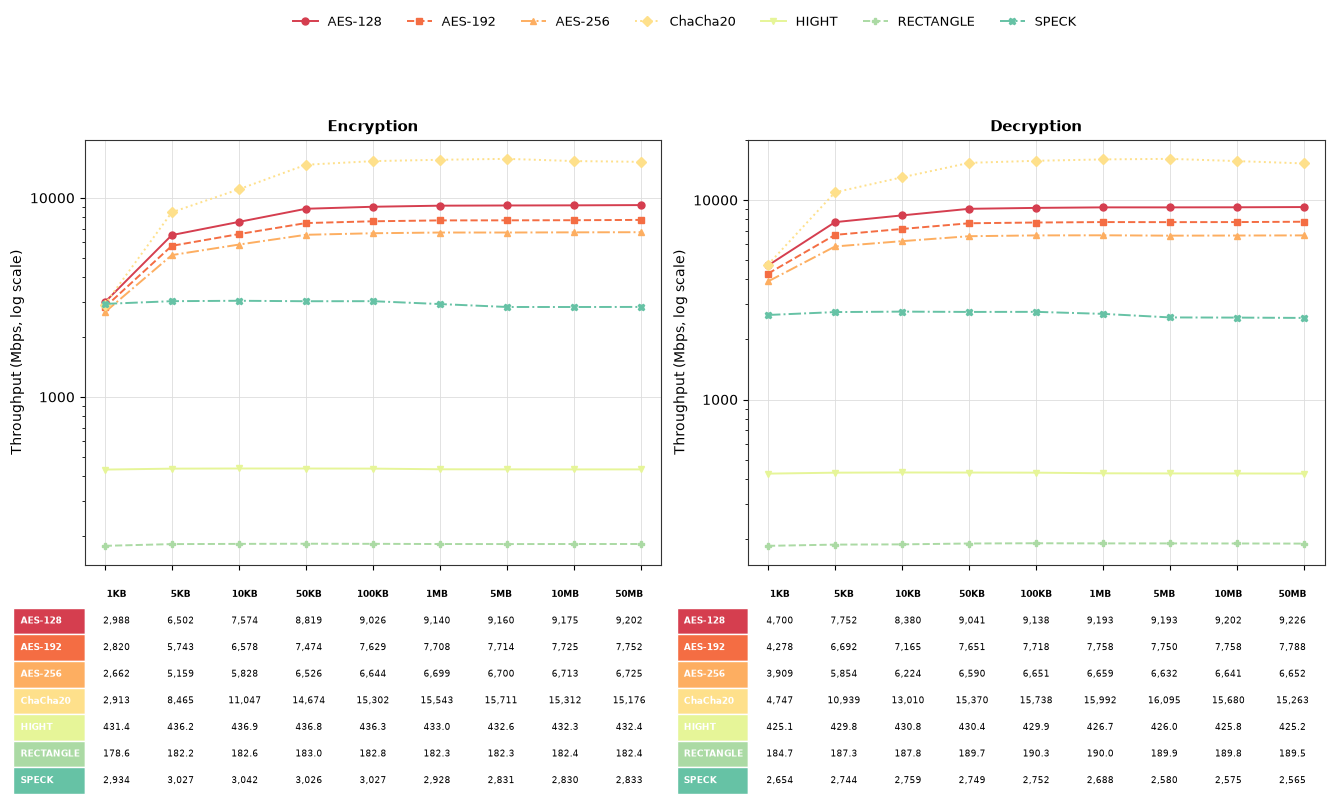

In [11]:
side_by_side_line_tables(
    p1, category_col="algorithm",
    enc_col="throughput_enc_mbps", dec_col="throughput_dec_mbps",
    out_name="fig_phase1_throughput_side_by_side",
)


### 5.3 Memory overhead beyond the data itself (side-by-side line chart + tables)


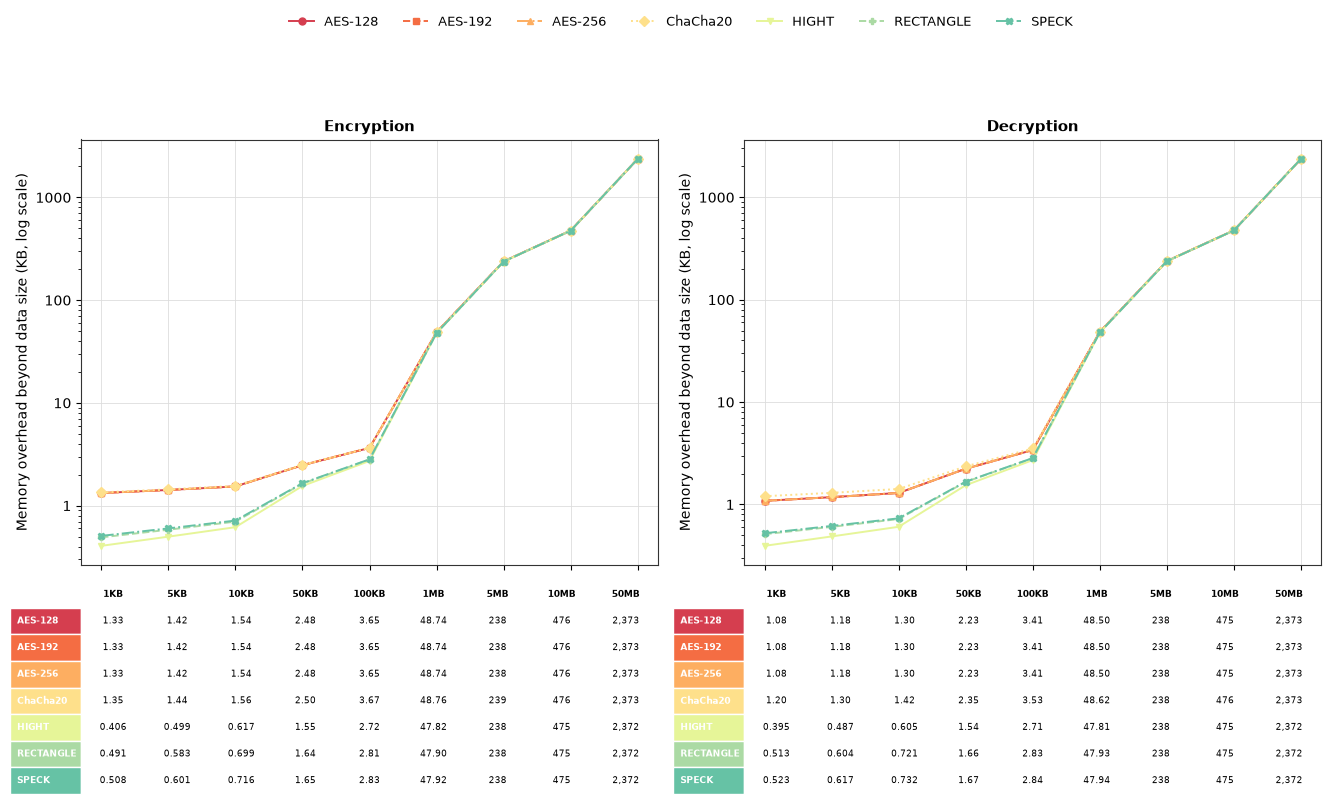

In [12]:
side_by_side_line_tables(
    p1, category_col="algorithm",
    enc_col="mem_overhead_enc_kb", dec_col="mem_overhead_dec_kb",
    out_name="fig_phase1_memory_overhead_side_by_side",
    value_fmt=fmt_kb, ylabel="Memory overhead beyond data size (KB, log scale)",
)


### 5.4 Per-block latency

Latency is defined per block (`enc_ms / n_blocks`), so it only applies
to block ciphers. **ChaCha20 is excluded**

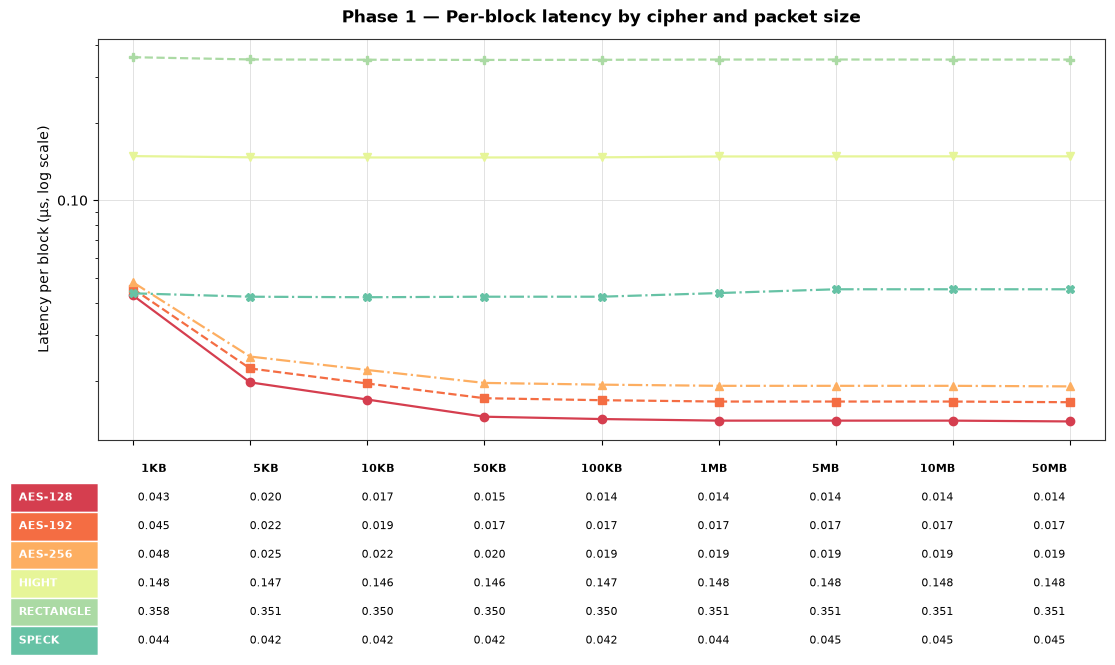

In [13]:
line_chart_with_table(
    p1, category_col="algorithm", value_col="latency_us",
    title="Phase 1 — Per-block latency by cipher and packet size",
    out_name="fig_phase1_latency_table",
    value_fmt=fmt_ms, ylabel="Latency per block (µs, log scale)",
)


### 5.5 Memory overhead as a percentage of data size

The absolute KB overhead above grows with payload size, which can
obscure how *significant* that overhead actually is relative to the
payload. As a percentage, the picture is sharper: overhead is
**~136% of the payload size at 1KB** (more overhead than the actual
data!), dropping below ~5% by 100KB and staying flat from there —
a strong argument for why small-packet IoT scenarios are disproportionately
memory-costly relative to their payload.

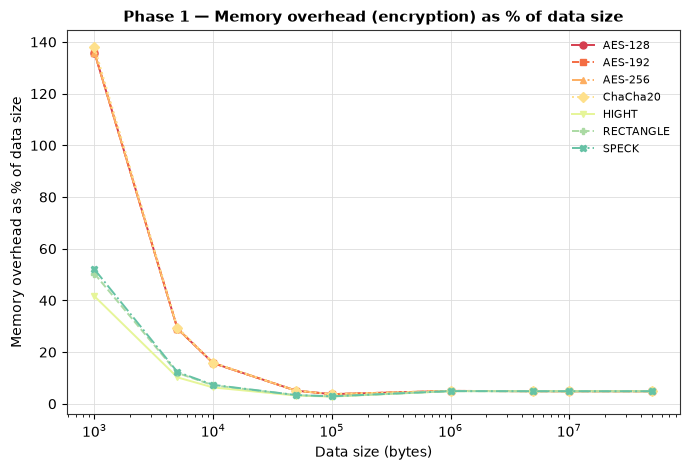

In [14]:
fig, ax = plt.subplots(figsize=(7, 4.8))
algos = sorted(p1["algorithm"].unique())
for i, algo in enumerate(algos):
    sub = p1[p1.algorithm == algo].sort_values("size_bytes")
    ax.plot(sub.size_bytes, sub.mem_overhead_enc_pct, marker=MARKERS[i], linestyle=LINESTYLES[i],
            color=PALETTE[i], markersize=5, linewidth=1.4, label=algo)
ax.set_xscale("log")
ax.set_xlabel("Data size (bytes)")
ax.set_ylabel("Memory overhead as % of data size")
ax.set_title("Phase 1 — Memory overhead (encryption) as % of data size", fontsize=11, fontweight="bold")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/fig_phase1_mem_overhead_pct.png", dpi=200, bbox_inches="tight")
fig.savefig(f"{OUT_DIR}/fig_phase1_mem_overhead_pct.pdf", bbox_inches="tight")
plt.show()


### 5.6 Decryption/encryption time ratio

A symmetry check: values near 1.0 mean encryption and decryption cost
roughly the same;

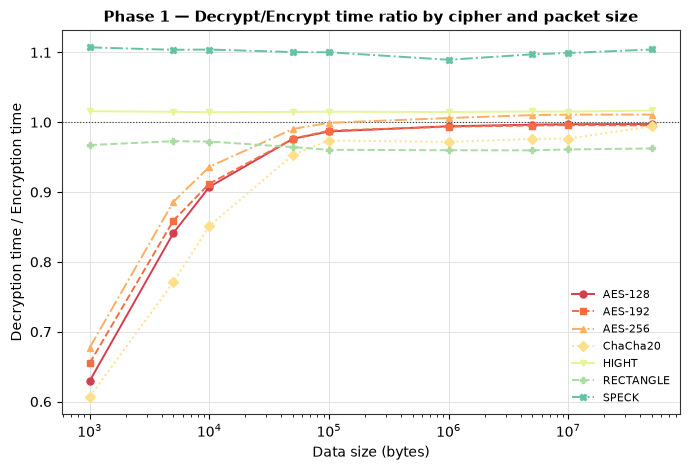

In [29]:
fig, ax = plt.subplots(figsize=(7, 4.8))
for i, algo in enumerate(algos):
    sub = p1[p1.algorithm == algo].sort_values("size_bytes")
    ax.plot(sub.size_bytes, sub.dec_enc_ratio, marker=MARKERS[i], linestyle=LINESTYLES[i],
            color=PALETTE[i], markersize=5, linewidth=1.4, label=algo)
ax.axhline(1.0, color="#333333", linewidth=0.8, linestyle=":", zorder=1)
ax.set_xscale("log")
ax.set_xlabel("Data size (bytes)")
ax.set_ylabel("Decryption time / Encryption time")
ax.set_title("Phase 1 — Decrypt/Encrypt time ratio by cipher and packet size", fontsize=11, fontweight="bold")
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/fig_phase1_dec_enc_ratio.png", dpi=200, bbox_inches="tight")
fig.savefig(f"{OUT_DIR}/fig_phase1_dec_enc_ratio.pdf", bbox_inches="tight")
plt.show()


### 5.7 Throughput vs. memory overhead trade-off (bubble chart, at 1 MB)

A trade-off view at a representative size (1MB): x = encryption
throughput, y = memory overhead, bubble size = per-block latency.
No single cipher wins on every axis — e.g. ChaCha20 leads throughput
but RECTANGLE/HIGHT win on memory overhead — which is the empirical
basis for an adaptive, constraint-driven cipher selection strategy
(the direction RQ2 is heading toward), without yet committing to
specific selection logic here.

**Note:** ChaCha20's bubble size is fixed rather than scaled, since
`latency_us` doesn't apply to stream ciphers (see 5.4).

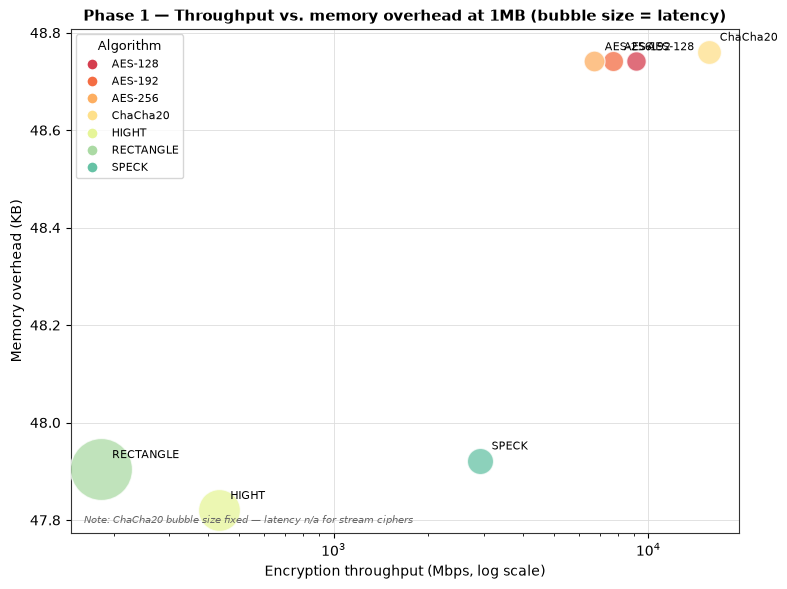

In [34]:
from matplotlib.lines import Line2D

size = "1MB"
sub = p1[p1.data_size == size].copy()

lat_valid = sub.dropna(subset=["latency_us"])
lat_min, lat_max = lat_valid["latency_us"].min(), lat_valid["latency_us"].max()

def bubble_size(v):
    if pd.isna(v):
        return 300
    norm = (v - lat_min) / (lat_max - lat_min)
    return 200 + 1800 * norm

fig, ax = plt.subplots(figsize=(8, 6))

for i, (_, row) in enumerate(sub.sort_values("algorithm").iterrows()):
    algo = row["algorithm"]
    color = PALETTE[i % len(PALETTE)]

    ax.scatter(
        row["throughput_enc_mbps"],
        row["mem_overhead_enc_kb"],
        s=bubble_size(row["latency_us"]),
        color=color,
        alpha=0.75,
        edgecolor="white",
        linewidth=1,
        zorder=3,
    )

    ax.annotate(
        algo,
        (row["throughput_enc_mbps"], row["mem_overhead_enc_kb"]),
        textcoords="offset points",
        xytext=(8, 8),
        fontsize=8
    )

ax.set_xscale("log")
ax.set_xlabel("Encryption throughput (Mbps, log scale)")
ax.set_ylabel("Memory overhead (KB)")
ax.set_title(
    f"Phase 1 — Throughput vs. memory overhead at {size} (bubble size = latency)",
    fontsize=11,
    fontweight="bold"
)

handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        color="w",
        markerfacecolor=PALETTE[i % len(PALETTE)],
        markeredgecolor="white",
        markeredgewidth=1,
        markersize=8,
        label=algo,
    )
    for i, algo in enumerate(sorted(sub["algorithm"].unique()))
]

ax.legend(
    handles=handles,
    title="Algorithm",
    loc="upper left",
    fontsize=8,
    title_fontsize=9,
    frameon=True
)

ax.text(
    0.02,
    0.02,
    "Note: ChaCha20 bubble size fixed — latency n/a for stream ciphers",
    transform=ax.transAxes,
    fontsize=7.5,
    style="italic",
    color="#666666"
)

fig.tight_layout()
fig.savefig(
    f"{OUT_DIR}/fig_phase1_throughput_vs_memory_bubble.png",
    dpi=200,
    bbox_inches="tight"
)
fig.savefig(
    f"{OUT_DIR}/fig_phase1_throughput_vs_memory_bubble.pdf",
    bbox_inches="tight"
)
plt.show()

## 6. Phase 2 — ECC key exchange + single cipher

Phase 2 pairs each cipher with an ECC key exchange. The CSV has one
extra column vs. Phase 1: `ecc_ms` — the key-exchange time, which is a
**fixed per-exchange cost** independent of payload size (in the
benchmark harness, ECC key-management iterations run before the
encryption operations so they don't interfere with the encryption
timers). The same derived columns as Phase 1 are computed here so all
the helper functions work unchanged.

In [17]:
p2 = pd.read_csv(os.path.join(CSV_DIR, "phase2_results.csv"))
p2["size_bytes"] = p2["data_size"].map(SIZE_BYTES)
p2["size_kb"] = p2["size_bytes"] / 1024

p2["total_enc_ms"] = p2["ecc_ms"] + p2["enc_ms"]
p2["ecc_share_pct"] = 100 * p2["ecc_ms"] / p2["total_enc_ms"]

def fmt_pct(v):
    if pd.isna(v):
        return ""
    return f"{v:.1f}"

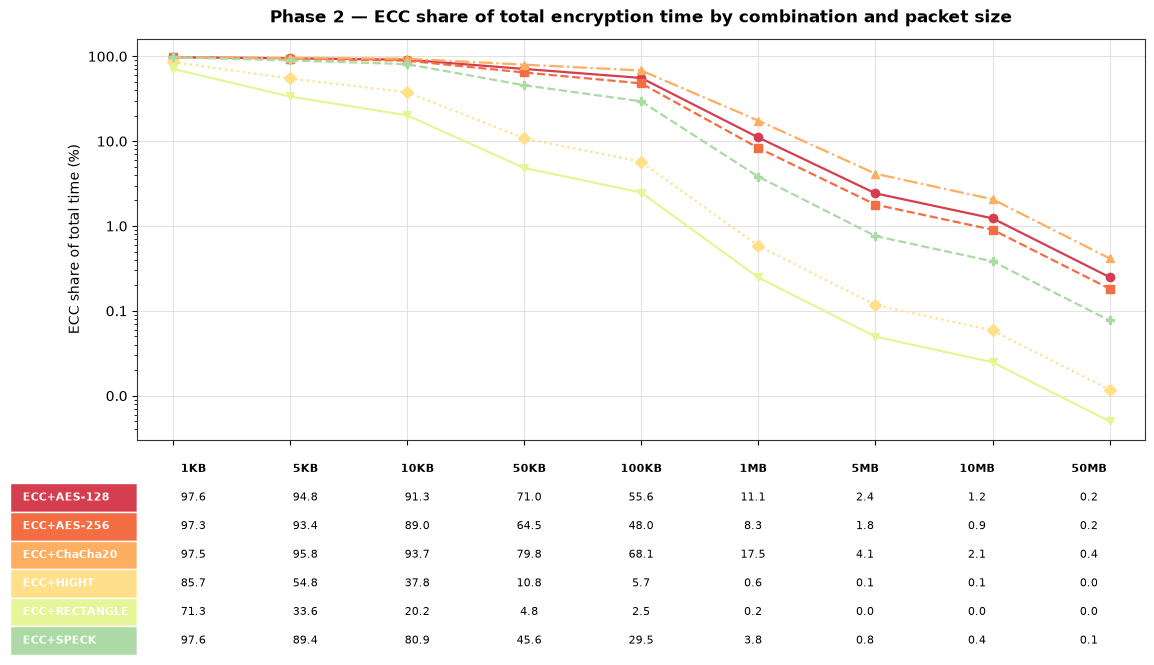

In [18]:
line_chart_with_table(
    p2, category_col="algorithm", value_col="ecc_share_pct",
    title="Phase 2 — ECC share of total encryption time by combination and packet size",
    out_name="fig_phase2_ecc_share",
    value_fmt=fmt_pct, ylabel="ECC share of total time (%)",
)

## 7. Phase 3 + 4 combined — cascade performance

Phase 3 (cascade only) and Phase 4 (ECC+cascade) don't share the exact
same set of cascade pairs. For the 5 pairs tested in both, Phase 4's
values are used (its `enc_ms`/`dec_ms` exclude the separate `ecc_ms`
column, so this reflects cascade-only cost either way). For the 2
pairs only tested in Phase 3 (`AES-128->HIGHT`, `HIGHT->RECTANGLE`),
Phase 3's values are used instead.

In [36]:
p3 = pd.read_csv(os.path.join(CSV_DIR, "phase3_results.csv"))
p4 = pd.read_csv(os.path.join(CSV_DIR, "phase4_results.csv"))

def normalize_cascade_name(name):
    parts = name.replace("ECC+", "").split("+")
    return "->".join(parts)

p4 = p4.copy()
p4["cascade"] = p4["cascade"].apply(normalize_cascade_name)

both = set(p3["cascade"].unique()) & set(p4["cascade"].unique())
p4_use = p4[p4["cascade"].isin(both)].drop(columns=["ecc_ms"])
p3_use = p3[~p3["cascade"].isin(both)]

p34 = pd.concat([p4_use, p3_use], ignore_index=True)
print(p34["cascade"].value_counts())

p34["size_bytes"] = p34["data_size"].map(SIZE_BYTES)
p34["size_kb"] = p34["size_bytes"] / 1024
p34["mem_overhead_enc_kb"] = p34["memory_enc_kb"] - 2 * p34["size_kb"]
p34["mem_overhead_dec_kb"] = p34["memory_dec_kb"] - 2 * p34["size_kb"]
p34["mem_overhead_enc_pct"] = 100 * p34["mem_overhead_enc_kb"] / p34["size_kb"]
p34["dec_enc_ratio"] = p34["dec_ms"] / p34["enc_ms"]

cascade
AES-128->AES-256     9
ChaCha20->AES-256    9
AES-128->SPECK       9
ChaCha20->SPECK      9
SPECK->HIGHT         9
AES-128->HIGHT       9
HIGHT->RECTANGLE     9
Name: count, dtype: int64


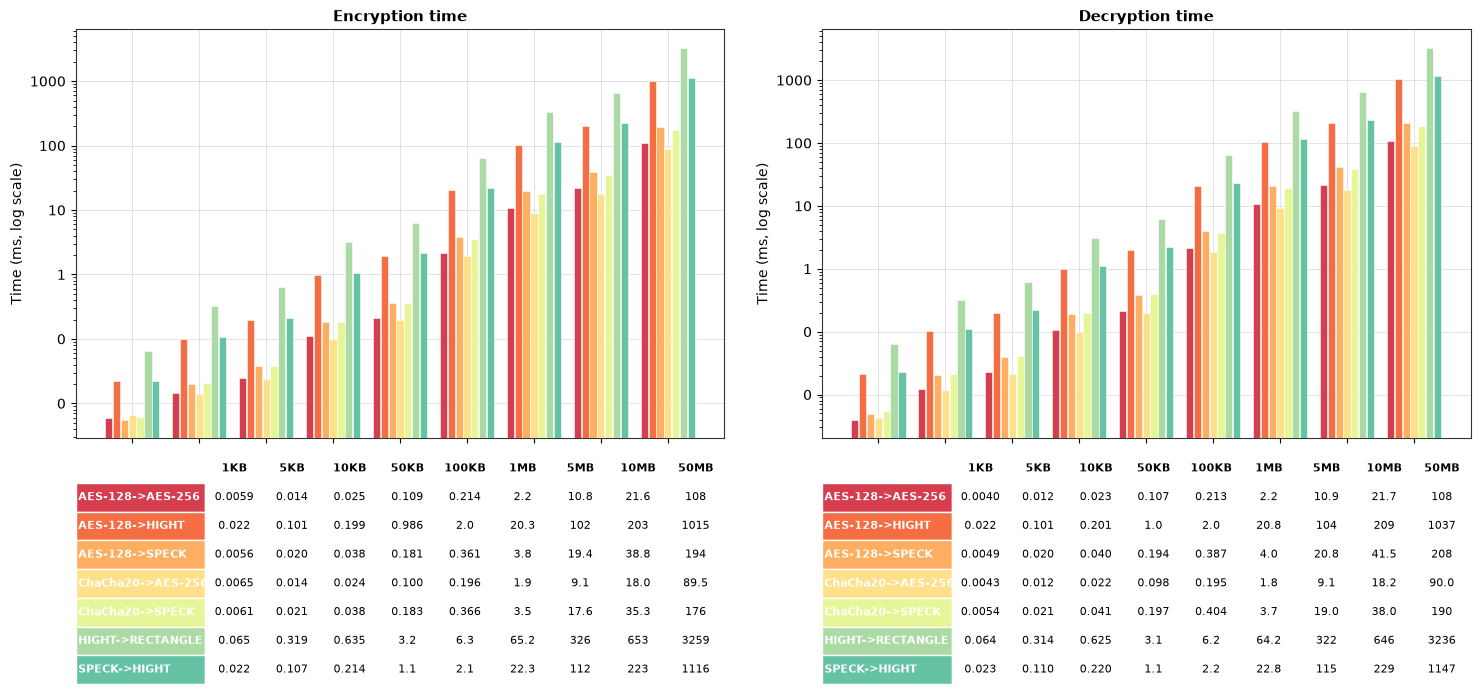

In [37]:
side_by_side_bar_tables(p34, "cascade", "enc_ms", "dec_ms", "fig_phase34_enc_dec_time")

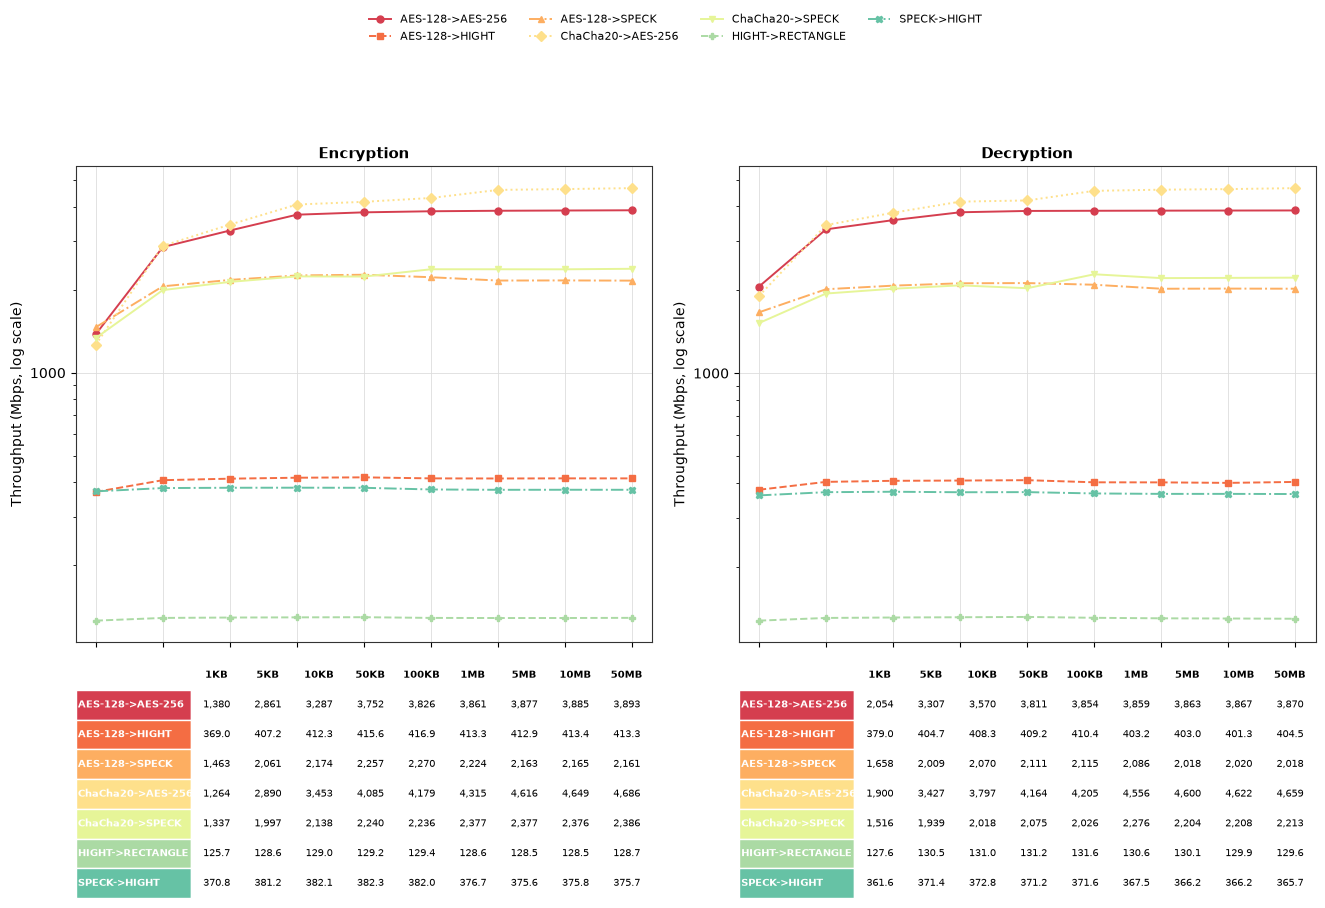

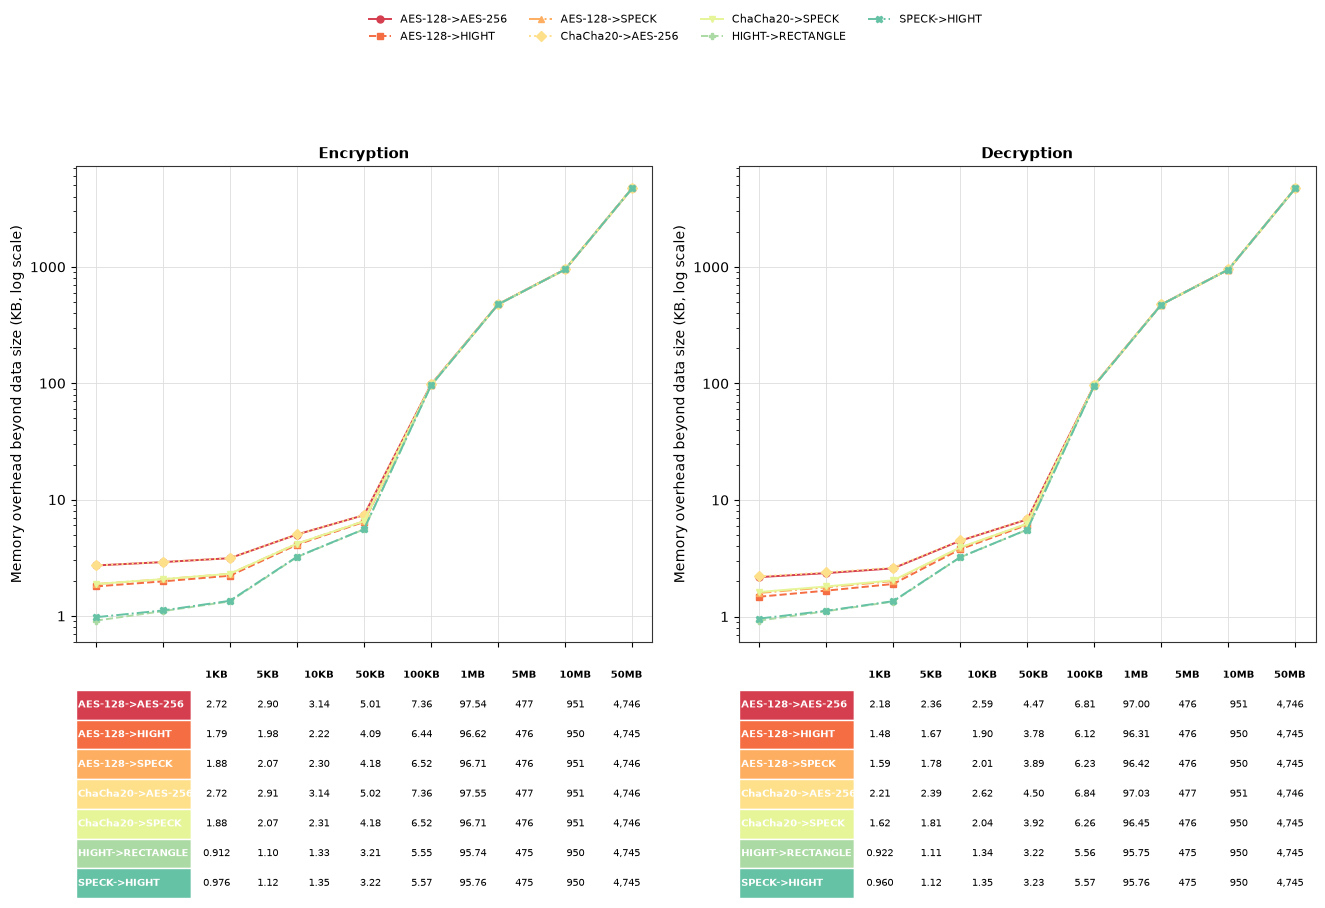

In [40]:
side_by_side_line_tables(
    p34, category_col="cascade",
    enc_col="throughput_enc_mbps", dec_col="throughput_dec_mbps",
    out_name="fig_phase34_throughput_side_by_side",
)

side_by_side_line_tables(
    p34, category_col="cascade",
    enc_col="mem_overhead_enc_kb", dec_col="mem_overhead_dec_kb",
    out_name="fig_phase34_memory_overhead_side_by_side",
    value_fmt=fmt_kb, ylabel="Memory overhead beyond data size (KB, log scale)",
)

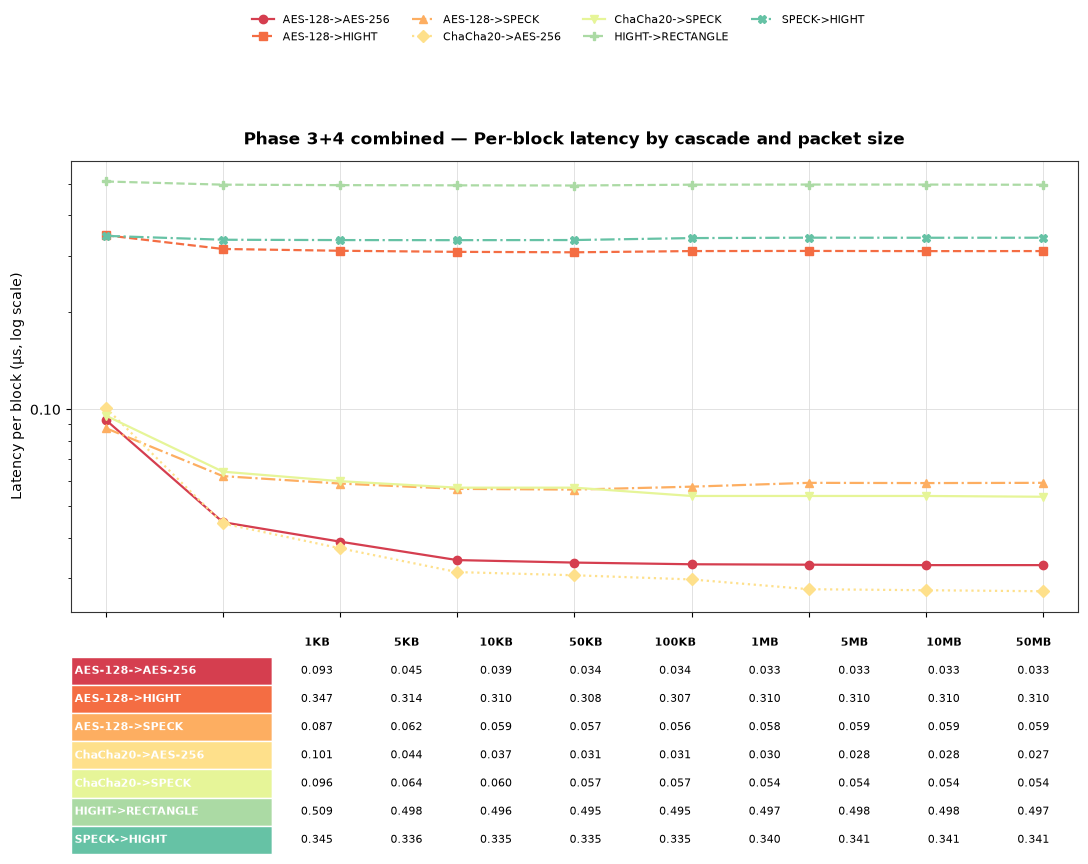

In [48]:
line_chart_with_table(
    p34, category_col="cascade", value_col="latency_us",
    title="Phase 3+4 combined — Per-block latency by cascade and packet size",
    out_name="fig_phase34_latency",
    value_fmt=fmt_ms, ylabel="Latency per block (µs, log scale)",
)

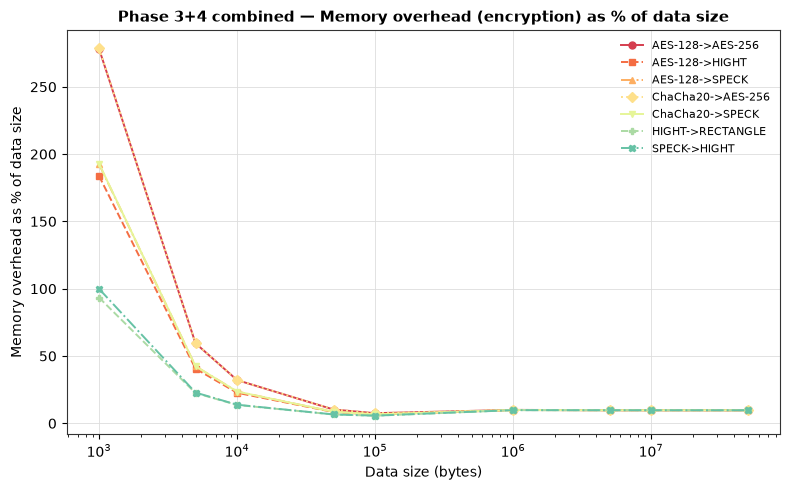

In [43]:
fig, ax = plt.subplots(figsize=(8, 5))
cascades = sorted(p34["cascade"].unique())
for i, c in enumerate(cascades):
    sub = p34[p34.cascade == c].sort_values("size_bytes")
    ax.plot(sub.size_bytes, sub.mem_overhead_enc_pct, marker=MARKERS[i], linestyle=LINESTYLES[i],
            color=PALETTE[i], markersize=5, linewidth=1.4, label=c)
ax.set_xscale("log")
ax.set_xlabel("Data size (bytes)")
ax.set_ylabel("Memory overhead as % of data size")
ax.set_title("Phase 3+4 combined — Memory overhead (encryption) as % of data size", fontsize=11, fontweight="bold")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/fig_phase34_mem_overhead_pct.png", dpi=200, bbox_inches="tight")
fig.savefig(f"{OUT_DIR}/fig_phase34_mem_overhead_pct.pdf", bbox_inches="tight")
plt.show()

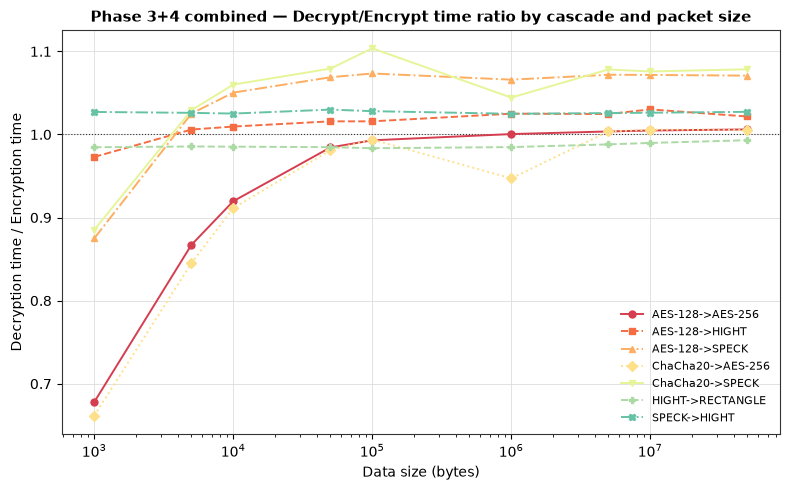

In [45]:
fig, ax = plt.subplots(figsize=(8, 5))
for i, c in enumerate(cascades):
    sub = p34[p34.cascade == c].sort_values("size_bytes")
    ax.plot(sub.size_bytes, sub.dec_enc_ratio, marker=MARKERS[i], linestyle=LINESTYLES[i],
            color=PALETTE[i], markersize=5, linewidth=1.4, label=c)
ax.axhline(1.0, color="#333333", linewidth=0.8, linestyle=":", zorder=1)
ax.set_xscale("log")
ax.set_xlabel("Data size (bytes)")
ax.set_ylabel("Decryption time / Encryption time")
ax.set_title("Phase 3+4 combined — Decrypt/Encrypt time ratio by cascade and packet size", fontsize=11, fontweight="bold")
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/fig_phase34_dec_enc_ratio.png", dpi=200, bbox_inches="tight")
fig.savefig(f"{OUT_DIR}/fig_phase34_dec_enc_ratio.pdf", bbox_inches="tight")
plt.show()

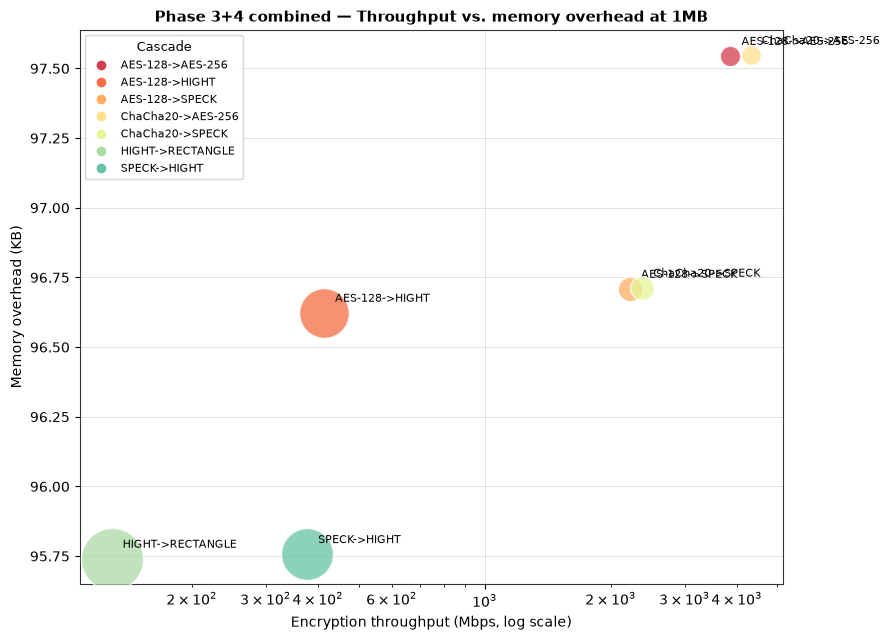

In [49]:
from matplotlib.lines import Line2D

size = "1MB"
sub = p34[p34.data_size == size].copy()

lat_valid = sub.dropna(subset=["latency_us"])
lat_min, lat_max = lat_valid["latency_us"].min(), lat_valid["latency_us"].max()

def bubble_size(v):
    if pd.isna(v):
        return 300
    norm = (v - lat_min) / (lat_max - lat_min)
    return 200 + 1800 * norm

fig, ax = plt.subplots(figsize=(9, 6.5))

# Plot bubbles
for i, (_, row) in enumerate(sub.sort_values("cascade").iterrows()):
    cascade = row["cascade"]
    color = PALETTE[i % len(PALETTE)]

    ax.scatter(
        row["throughput_enc_mbps"],
        row["mem_overhead_enc_kb"],
        s=bubble_size(row["latency_us"]),
        color=color,
        alpha=0.75,
        edgecolor="white",
        linewidth=1,
        zorder=3,
    )

    ax.annotate(
        cascade,
        (row["throughput_enc_mbps"], row["mem_overhead_enc_kb"]),
        textcoords="offset points",
        xytext=(8, 8),
        fontsize=8,
    )

ax.set_xscale("log")
ax.set_xlabel("Encryption throughput (Mbps, log scale)")
ax.set_ylabel("Memory overhead (KB)")
ax.set_title(
    f"Phase 3+4 combined — Throughput vs. memory overhead at {size}",
    fontsize=11,
    fontweight="bold"
)

# Custom legend with fixed-size markers (colors only)
handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        color="w",
        markerfacecolor=PALETTE[i % len(PALETTE)],
        markeredgecolor="white",
        markeredgewidth=1,
        markersize=8,
        label=cascade,
    )
    for i, cascade in enumerate(sorted(sub["cascade"].unique()))
]

ax.legend(
    handles=handles,
    title="Cascade",
    loc="upper left",
    fontsize=8,
    title_fontsize=9,
    frameon=True
)

fig.tight_layout()
fig.savefig(
    f"{OUT_DIR}/fig_phase34_throughput_vs_memory_bubble.png",
    dpi=200,
    bbox_inches="tight",
)
fig.savefig(
    f"{OUT_DIR}/fig_phase34_throughput_vs_memory_bubble.pdf",
    bbox_inches="tight",
)
plt.show()

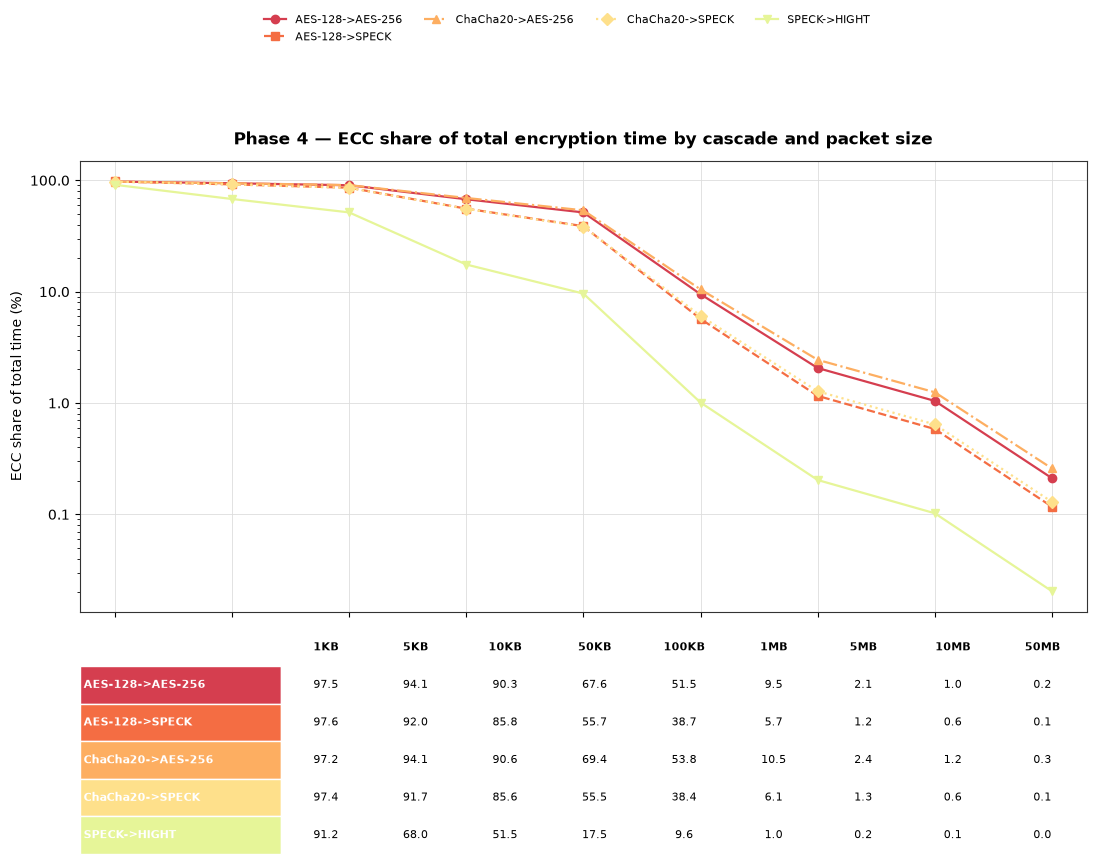

In [50]:
p4 = pd.read_csv(os.path.join(CSV_DIR, "phase4_results.csv"))

# Normalize "ECC+A+B" -> "A->B" to match the arrow convention used elsewhere
p4["cascade"] = p4["cascade"].apply(lambda n: "->".join(n.replace("ECC+", "").split("+")))

p4["total_enc_ms"] = p4["ecc_ms"] + p4["enc_ms"]
p4["ecc_share_pct"] = 100 * p4["ecc_ms"] / p4["total_enc_ms"]

def fmt_pct(v):
    if pd.isna(v):
        return ""
    return f"{v:.1f}"

line_chart_with_table(
    p4, category_col="cascade", value_col="ecc_share_pct",
    title="Phase 4 — ECC share of total encryption time by cascade and packet size",
    out_name="fig_phase4_ecc_share",
    value_fmt=fmt_pct, ylabel="ECC share of total time (%)",
)